# LR12

### Упражнение 1 

- Вычислить карту бифуркации системы Ресслера. 
- Оставьте фиксированными параметры $a = b = 0.2$. 
- Измените параметр $c$, как показано ниже. 
- Для каждого значения $c$ вычислите и постройте локальные максимумы временного ряда $z(t)$, используя функцию `scipy.signal.find_peaks`. У вас должен получиться график, похожий на рисунок ниже. 
- Определите первую точку бифуркации, прежде чем система станет хаотичной. 
- Объясните, почему для логистической карты не требовалось вычисление локальных максимумов (пиков).

<img src="https://github.com/fmi-ml-courses/ts-magi-2025-2026/blob/main/data/l11/rossler_attractor.png?raw=1" style="width: 100%; display: block; margin: auto;">

In [ ]:
c_values = np.linspace(2, 15, 300) # value of c to explore

### Упражнение 2 

- Вычислите (фрактальную) размерность объекта, показанного на рисунке ниже.

<img src="https://github.com/fmi-ml-courses/ts-magi-2025-2026/blob/main/data/l11/menger-sr.jpeg?raw=1" style="width: 40%; display: block; margin: auto;">

### Упражнение 3 

- Постройте аттрактор Лоренца для $\sigma = 10$, $\rho = 28$ и $\beta = \frac{8}{3}$.

### Упражнение 4 

- Используйте вложение Taken, чтобы восстановить аттрактор Лоренца по временному ряду его первой переменной состояния $x(t)$. 
- Вычислите оптимальную временную задержку $\tau$ и оптимальную размерность вложения $m$, используя алгоритмы взаимной информации и ложных ближайших соседей.

### Упражнение 5 

- Вычислите прогнозы переменной состояния $x(t)$ системы Лоренца, используя вложения задержки Taken и алгоритм регрессии по вашему выбору (регрессия Риджа, случайный лес и т. д.).

### Упражнение 6 

- Вычислите прогнозы переменной состояния $x(t)$ системы Лоренца с помощью ESN, используя горизонт прогнозирования по вашему выбору. 
- Создайте трехмерный график состояний Резервуара, уменьшенный до трех измерений с помощью PCA, и сравните его с реальным аттрактором Лоренца.

# ____________________________________________________________________________________________________

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -U -qq reservoir_computing tsa_course

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
from reservoir_computing.reservoir import Reservoir
from reservoir_computing.utils import make_forecasting_dataset
from tsa_course.lecture11 import computeLE, plot_bifurcation_diagram

np.random.seed(0)


In [2]:
# Система Рёсслера
def rossler_system(t, y, a, b, c):
    x, y_, z = y
    dxdt = -y_ - z
    dydt = x + a * y_
    dzdt = b + z * (x - c)
    return [dxdt, dydt, dzdt]

# Система Лоренца
def lorenz(t, x, sigma, rho, beta):
    res = np.zeros_like(x)
    res[0] = sigma * (x[1] - x[0])
    res[1] = x[0] * (rho - x[2]) - x[1]
    res[2] = x[0] * x[1] - beta * x[2]
    return res

# Якобиан Лоренца
def lorenz_jac(t, x, sigma, rho, beta):
    res = np.zeros((x.shape[0], x.shape[0]))
    res[0, 0], res[0, 1] = -sigma, sigma
    res[1, 0], res[1, 1], res[1, 2] = rho - x[2], -1., -x[0]
    res[2, 0], res[2, 1], res[2, 2] = x[1], x[0], -beta
    return res

# Вложение Такенса
def takens_embedding(data, delay, dimension):
    embedding = np.array([data[0:len(data) - delay * dimension]])
    for i in range(1, dimension):
        embedding = np.append(
            embedding,
            [data[i * delay:len(data) - delay * (dimension - i)]],
            axis=0
        )
    return embedding.transpose()

# Взаимная информация
def mutual_information(data, delay, n_bins):
    delayed_data = data[delay:]
    original_data = data[:-delay]
    p_x, bin_edges = np.histogram(original_data, bins=n_bins, density=True)
    p_y, _ = np.histogram(delayed_data, bins=bin_edges, density=True)
    p_xy, _, _ = np.histogram2d(original_data, delayed_data, bins=bin_edges, density=True)
    mutual_info = 0
    for i in range(n_bins):
        for j in range(n_bins):
            if p_xy[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                mutual_info += p_xy[i, j] * np.log(p_xy[i, j] / (p_x[i] * p_y[j]))
    return mutual_info

# Ложные ближайшие соседи
def calculate_fnn(data, delay, max_emb_dim, R_tol=10):
    fnn_proportions = []
    for m in range(1, max_emb_dim + 1):
        emb_m = takens_embedding(data, delay, m)
        emb_m_plus_one = takens_embedding(data, delay, m + 1)
        nbrs = NearestNeighbors(n_neighbors=2).fit(emb_m[:-delay])
        distances, indices = nbrs.kneighbors(emb_m[:-delay])
        n_false_nn = 0
        for i in range(len(distances)):
            neighbor_index, R_m = indices[i, 1], distances[i, 1]
            R_m_plus_one = np.linalg.norm(emb_m_plus_one[i] - emb_m_plus_one[neighbor_index])
            if R_m > 0 and abs(R_m_plus_one - R_m) / R_m > R_tol:
                n_false_nn += 1
        fnn_proportions.append(n_false_nn / len(indices))
    return fnn_proportions

# Построение аттрактора
def plot_attractor(data, title="", interactive=False):
    xt, yt, zt = data[0], data[1], data[2]
    if interactive:
        fig = go.Figure(data=[go.Scatter3d(
            x=xt, y=yt, z=zt, mode='lines',
            line=dict(color='black', width=1)
        )])
        fig.update_layout(
            title=title,
            scene=dict(xaxis_title='x(t)', yaxis_title='y(t)', zaxis_title='z(t)'),
            autosize=False, width=800, height=600,
            margin=dict(l=0, r=0, b=0, t=0)
        )
        fig.show()
    else:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(xt, yt, zt, linewidth=0.2, alpha=0.7, color='k')
        ax.set_title(title)
        ax.set_xlabel('x(t)')
        ax.set_ylabel('y(t)')
        ax.set_zlabel('z(t)')
        plt.show()


### Упражнение 1

#### 1. Генерация решений системы Рёсслера и сбор локальных максимумов z(t)

In [3]:
c_values = np.linspace(2, 15, 300)

a, b = 0.2, 0.2
y0 = [0.0, 2.0, 0.0]
T_transient = 200   # время для выхода на аттрактор
T_record    = 300   # время записи

bif_c  = []
bif_z  = []

for c in c_values:
    sol_trans = solve_ivp(rossler_system, [0, T_transient], y0,
                          args=(a, b, c), dense_output=True)
    y_trans_end = sol_trans.sol(T_transient)

    sol = solve_ivp(rossler_system, [0, T_record], y_trans_end,
                    args=(a, b, c), dense_output=True)
    t_rec = np.linspace(0, T_record, 5000)
    sol_y = sol.sol(t_rec)
    z = sol_y[2]

    # Локальные максимумы z(t)
    peaks, _ = find_peaks(z)
    z_peaks = z[peaks]

    bif_c.extend([c] * len(z_peaks))
    bif_z.extend(z_peaks.tolist())

bif_c = np.array(bif_c)
bif_z = np.array(bif_z)
print(f"Собрано точек для диаграммы: {len(bif_c)}")


Собрано точек для диаграммы: 17805


#### 2. Построение карты бифуркации

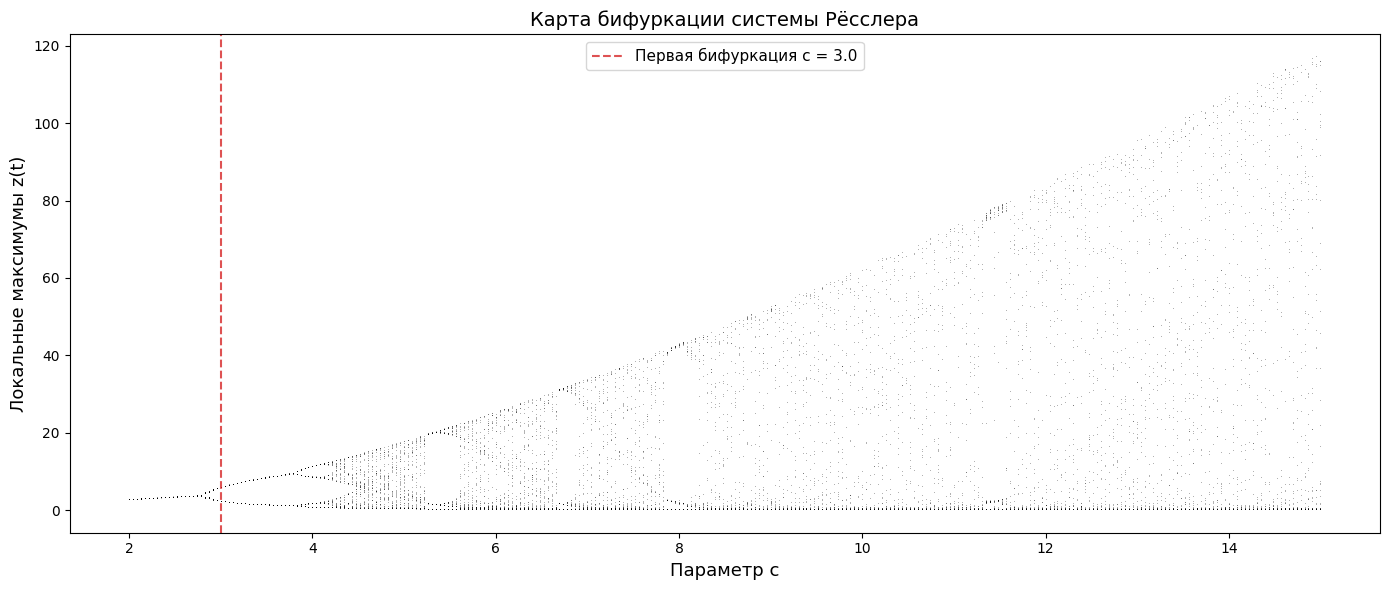

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bif_c, bif_z, ',k', alpha=0.3, markersize=0.5)
ax.set_xlabel('Параметр c', fontsize=13)
ax.set_ylabel('Локальные максимумы z(t)', fontsize=13)
ax.set_title('Карта бифуркации системы Рёсслера', fontsize=14)

first_bif_c = 3.0
ax.axvline(first_bif_c, color='tab:red', linestyle='--', alpha=0.8,
           label=f'Первая бифуркация c = {first_bif_c}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


плоховато, конечно, видно, но вроде как соответствует рисунку в начале. бифуркация начинается чуть раньше 3.0

### Упражнение 2

#### 1. Аналитическое вычисление размерности

In [5]:
N_menger = 20   # число остающихся кубиков после одной итерации
r_menger = 3    # коэффициент масштабирования

D_menger = np.log(N_menger) / np.log(r_menger)


print("Губка Менгера")
print(f"Число самоподобных частей N = {N_menger}")
print(f"Коэффициент масштабирования r = {r_menger}")
print(f"Фрактальная размерность D = log({N_menger}) / log({r_menger})")
print(f"D = {np.log(N_menger):.4f} / {np.log(r_menger):.4f}")
print(f"D =(примерно) {D_menger:.4f}")

Губка Менгера
Число самоподобных частей N = 20
Коэффициент масштабирования r = 3
Фрактальная размерность D = log(20) / log(3)
D = 2.9957 / 1.0986
D =(примерно) 2.7268


получилось, что больше 2, но меньше 3 D = 2.7268 это и есть мера того, насколько она заполняет пространство

#### 2. Сравнение с другими фракталами

Объект                                  N     r        D
--------------------------------------------------------
Линия (D=1)                             2     2   1.0000
Квадрат (D=2)                           4     2   2.0000
Куб (D=3)                               8     2   3.0000
Кривая Коха                             4     3   1.2619
Треугольник Серпинского                 3     2   1.5850
Губка Менгера                          20     3   2.7268


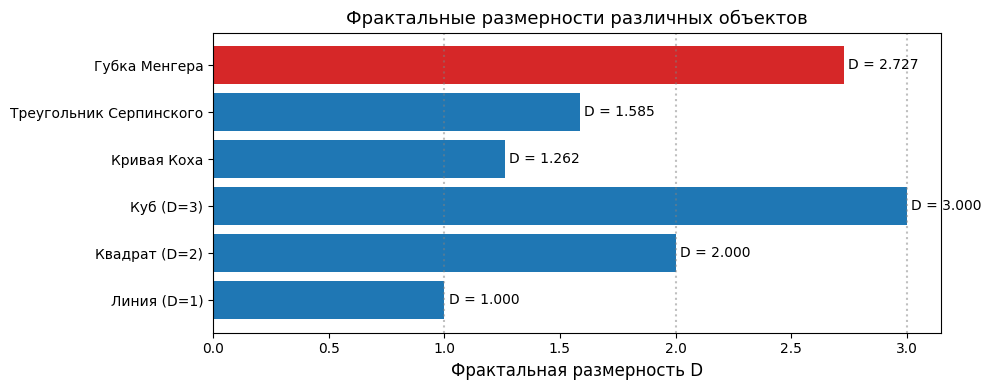

In [6]:
fractals = {
    'Линия (D=1)':               (2, 2),
    'Квадрат (D=2)':             (4, 2),
    'Куб (D=3)':                 (8, 2),
    'Кривая Коха':               (4, 3),
    'Треугольник Серпинского':   (3, 2),
    'Губка Менгера':             (20, 3),
}

print(f"{'Объект':<35} {'N':>5} {'r':>5} {'D':>8}")
print("-" * 56)
for name, (N, r) in fractals.items():
    D = np.log(N) / np.log(r)
    print(f"{name:<35} {N:>5} {r:>5} {D:>8.4f}")

# Визуализация
names = list(fractals.keys())
dims  = [np.log(N)/np.log(r) for N, r in fractals.values()]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['tab:blue' if 'Менгера' not in n else 'tab:red' for n in names]
bars = ax.barh(names, dims, color=colors)
ax.set_xlabel('Фрактальная размерность D', fontsize=12)
ax.set_title('Фрактальные размерности различных объектов', fontsize=13)
ax.axvline(1, color='gray', linestyle=':', alpha=0.5)
ax.axvline(2, color='gray', linestyle=':', alpha=0.5)
ax.axvline(3, color='gray', linestyle=':', alpha=0.5)
for bar, d in zip(bars, dims):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'D = {d:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()


Губка Менгера почти как куб D = 2.73, но из неё бесконечно вырезали дыры, поэтому она так и не стала полноценно трёхмерной

Обычные фигуры имеют целую размерность: линия - 1, квадрат - 2, куб - 3

### Упражнение 3

#### 1. Решение системы ОДУ Лоренца

In [ ]:
sigma, rho, beta = 10., 28., 8/3
x0_lorenz = np.array([1.5, -1.5, 20.])
T_lorenz   = 60

sol_lorenz = solve_ivp(lorenz, [0, T_lorenz], x0_lorenz,
                        args=(sigma, rho, beta), dense_output=True, max_step=0.01)
t_lor = np.linspace(0, T_lorenz, 30000)
lor_sol = sol_lorenz.sol(t_lor)

print(f"Форма решения {lor_sol.shape}  (3 переменные x {lor_sol.shape[1]} точек)")
print(f"x: [{lor_sol[0].min():.2f}, {lor_sol[0].max():.2f}]")
print(f"y: [{lor_sol[1].min():.2f}, {lor_sol[1].max():.2f}]")
print(f"z: [{lor_sol[2].min():.2f}, {lor_sol[2].max():.2f}]")


Форма решения (3, 30000)  (3 переменные x 30000 точек)
x: [-16.98, 18.82]
y: [-22.28, 25.74]
z: [3.33, 46.34]


#### 2. Временные ряды переменных Лоренца

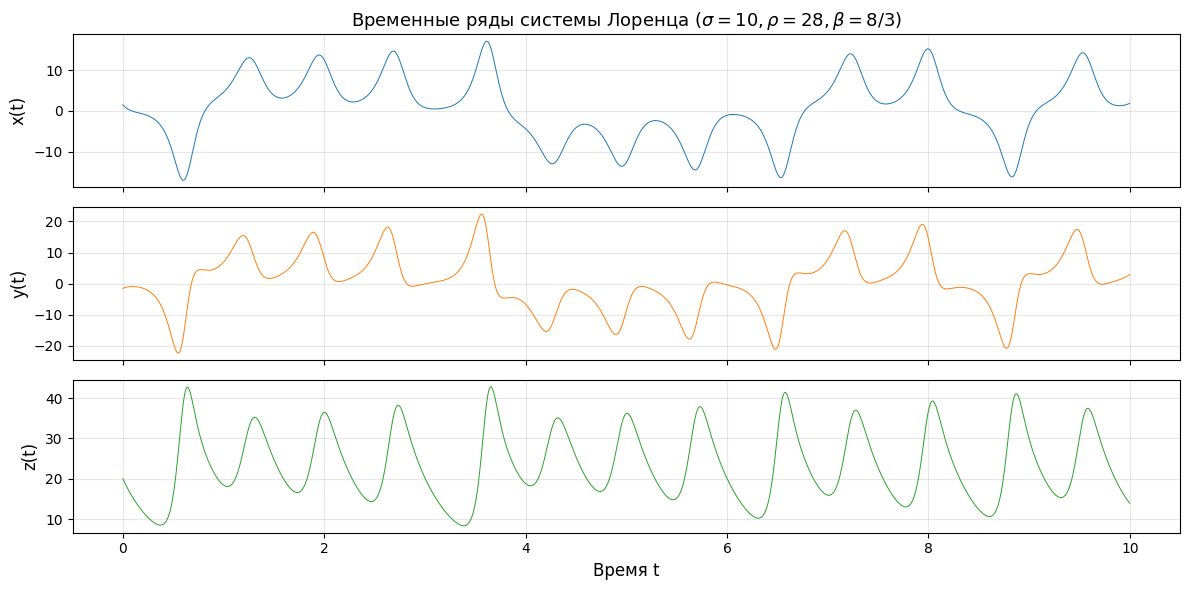

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
labels = ['x(t)', 'y(t)', 'z(t)']
colors = ['tab:blue', 'tab:orange', 'tab:green']
for i, (ax, lbl, col) in enumerate(zip(axes, labels, colors)):
    ax.plot(t_lor[:5000], lor_sol[i, :5000], color=col, lw=0.7)
    ax.set_ylabel(lbl, fontsize=12)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Время t', fontsize=12)
axes[0].set_title('Временные ряды системы Лоренца ($\sigma=10, \\rho=28, \\beta=8/3$)', fontsize=13)
plt.tight_layout()
plt.show()


ни один цикл в точности не повторяет предыдущий - хаос)

#### 3. Аттрактор Лоренца в 3D

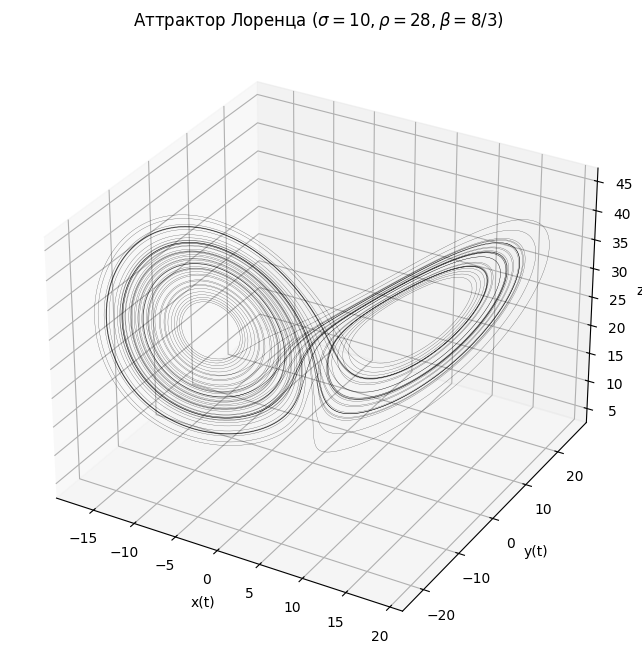

In [9]:
plot_attractor(lor_sol, title='Аттрактор Лоренца ($\sigma=10, \\rho=28, \\beta=8/3$)', interactive=False)

получилась бабочка))

Траектория хаотически наматывается на две «лопасти», никогда в точности не повторяя себя, но всегда оставаясь внутри одной компактной формы

#### 4. Чувствительность к начальным условиям (эффект бабочки)

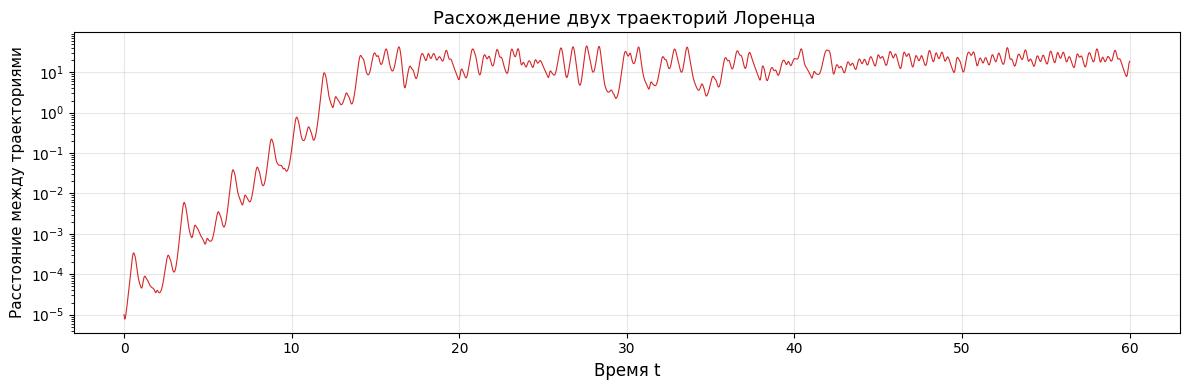

In [10]:
x0_perturbed = x0_lorenz + np.array([1e-5, 0, 0])

sol_p = solve_ivp(lorenz, [0, T_lorenz], x0_perturbed,
                  args=(sigma, rho, beta), dense_output=True, max_step=0.01)
lor_sol_p = sol_p.sol(t_lor)

distance = np.linalg.norm(lor_sol - lor_sol_p, axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(t_lor, distance, color='tab:red', lw=0.8)
ax.set_xlabel('Время t', fontsize=12)
ax.set_ylabel('Расстояние между траекториями', fontsize=11)
ax.set_title('Расхождение двух траекторий Лоренца ', fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Примерно при t = 20-30 траектории полностью расходятся, график показывает экспоненциальный рост

## Упражнение 4

#### 1. Подготовка временного ряда x(t) системы Лоренца

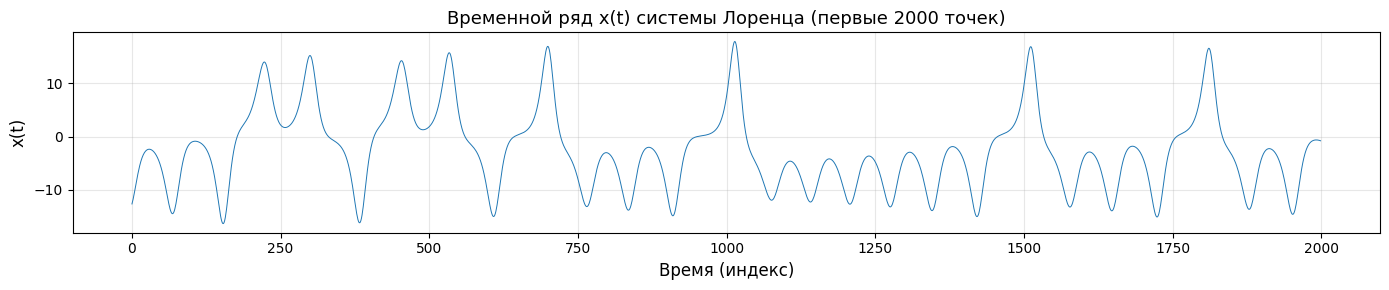

Длина ряда: 19500 точек


In [11]:
# Генерируем длинный ряд для оценки параметров
T_long = 200
sol_long = solve_ivp(lorenz, [0, T_long], x0_lorenz,
                     args=(sigma, rho, beta), dense_output=True, max_step=0.01)
t_long = np.linspace(0, T_long, int(2e4))
lor_long = sol_long.sol(t_long)

lorenz_x = lor_long[0, 500:]

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(lorenz_x[:2000], lw=0.7, color='tab:blue')
ax.set_xlabel('Время (индекс)', fontsize=12)
ax.set_ylabel('x(t)', fontsize=12)
ax.set_title('Временной ряд x(t) системы Лоренца (первые 2000 точек)', fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Длина ряда: {len(lorenz_x)} точек")


непериодические колебания с хаотической сменой знака

#### 2. Оценка оптимальной временной задержки τ

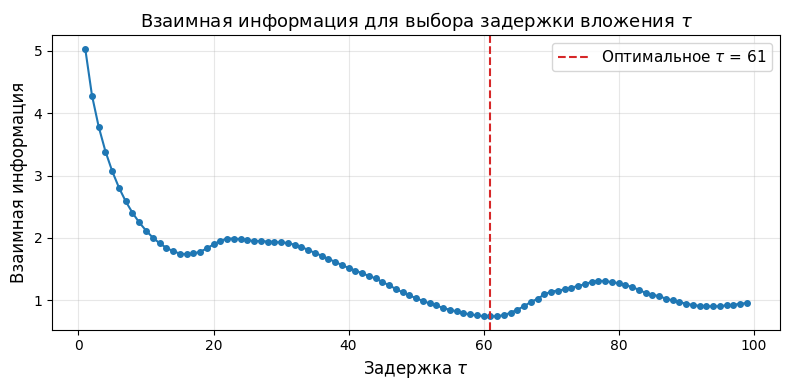

Оптимальная задержка τ = 61


In [13]:
MI_lorenz = []
tau_range = range(1, 100)
for tau in tau_range:
    mi = mutual_information(lorenz_x, tau, n_bins=50)
    MI_lorenz.append(mi)

tau_opt = tau_range[np.argmin(MI_lorenz)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(tau_range), MI_lorenz, 'o-', color='tab:blue', markersize=4)
ax.axvline(tau_opt, color='tab:red', linestyle='--',
           label=f'Оптимальное $\\tau$ = {tau_opt}')
ax.set_xlabel('Задержка $\\tau$', fontsize=12)
ax.set_ylabel('Взаимная информация', fontsize=12)
ax.set_title('Взаимная информация для выбора задержки вложения $\\tau$', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Оптимальная задержка τ = {tau_opt}")


#### 3. Оценка размерности вложения m (ложные ближайшие соседи)

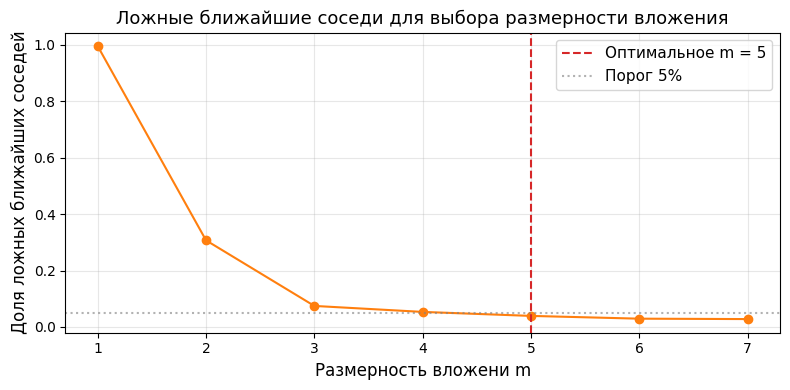

Оптимальная размерность вложения m = 5


In [14]:
fnn_lorenz = calculate_fnn(lorenz_x, delay=tau_opt, max_emb_dim=7)

m_opt = next((i+1 for i, f in enumerate(fnn_lorenz) if f < 0.05), len(fnn_lorenz))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(fnn_lorenz)+1), fnn_lorenz, 'o-', color='tab:orange', markersize=6)
ax.axvline(m_opt, color='tab:red', linestyle='--',
           label=f'Оптимальное m = {m_opt}')
ax.axhline(0.05, color='gray', linestyle=':', alpha=0.6, label='Порог 5%')
ax.set_xlabel('Размерность вложени m', fontsize=12)
ax.set_ylabel('Доля ложных ближайших соседей', fontsize=12)
ax.set_title('Ложные ближайшие соседи для выбора размерности вложения', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Оптимальная размерность вложения m = {m_opt}")


При m = 1 почти все соседи оказываются ложными. С каждым новым измерением доля ложных соседей быстро падает. При m = 5 она впервые опускается ниже порога 5%

## Упражнение 5

Используем два алгоритма для сравнения:
- Ridge-регрессия (линейная, быстрая)
- Random Forest(нелинейная, точнее для хаоса)

#### 1. Подготовка данных

In [15]:
delay_forecast = tau_opt
dim_forecast   = m_opt + 1 

emb_full = takens_embedding(lorenz_x, delay=delay_forecast, dimension=dim_forecast)
X_full = emb_full[:, :-1]   # признаки
y_full = emb_full[:, -1]    # цель

test_size = int(len(y_full) * 0.15)
X_train, X_test = X_full[:-test_size], X_full[-test_size:]
y_train, y_test = y_full[:-test_size], y_full[-test_size:]

print(f"Обучающая выборка X={X_train.shape}, y={y_train.shape}")
print(f"Тестовая выборка  X={X_test.shape}, y={y_test.shape}")
print(f"Горизонт прогноза {delay_forecast} шагов вперёд")


Обучающая выборка X=(16264, 5), y=(16264,)
Тестовая выборка  X=(2870, 5), y=(2870,)
Горизонт прогноза 61 шагов вперёд


#### 2. Обучение моделей и прогнозирование

In [16]:
# Ridge регрессия
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
preds_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, preds_ridge)

# Random Forest
rf = RandomForestRegressor(n_estimators=100).fit(X_train, y_train)
preds_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, preds_rf)

print(f"Ridge  MSE {mse_ridge:.4f}")
print(f"Random Forest MSE {mse_rf:.4f}")


Ridge  MSE 63.6234
Random Forest MSE 5.1693


линейная модель плохо справляется, потому что динамика Лоренца нелинейна, а горизонт прогноза (61 шаг) большой

Random Forest справился в 12 раз лучше, нелинейная модель гораздо эффективнее улавливает структуру

#### 3. Визуализация прогнозов

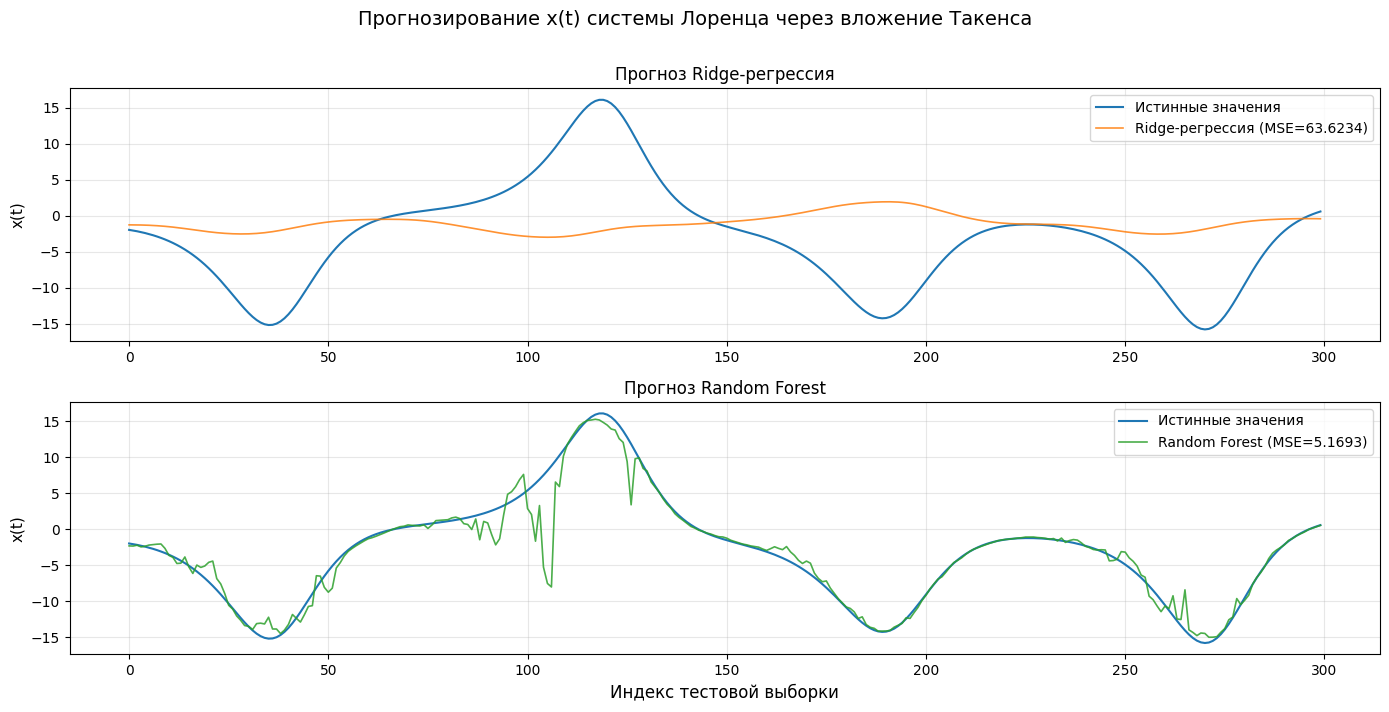

In [17]:
n_plot = 300
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax, preds, mse, name, col in zip(
    axes,
    [preds_ridge, preds_rf],
    [mse_ridge, mse_rf],
    ['Ridge-регрессия', 'Random Forest'],
    ['tab:orange', 'tab:green']
):
    ax.plot(y_test[:n_plot], label='Истинные значения', color='tab:blue', lw=1.5)
    ax.plot(preds[:n_plot], label=f'{name} (MSE={mse:.4f})', color=col, lw=1.2, alpha=0.85)
    ax.set_ylabel('x(t)', fontsize=11)
    ax.set_title(f'Прогноз {name}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Индекс тестовой выборки', fontsize=12)
plt.suptitle('Прогнозирование x(t) системы Лоренца через вложение Такенса', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


Ridge практически не улавливает динамику.

Random Forest в целом хорошо следует за истинным рядом, однако в районе индексов 100-130 виден резкий выброc

## Упражнение 6

#### 1. Подготовка датасета

In [18]:
horizon = 5  # горизонт прогноза (шагов вперёд)

Xtr, Ytr, Xte, Yte, scaler = make_forecasting_dataset(
    lorenz_x[:, None],
    horizon=horizon,
    test_percent=0.15
)
print(f"Обучение  Xtr={Xtr.shape}, Ytr={Ytr.shape}")
print(f"Тест     Xte={Xte.shape}, Yte={Yte.shape}")
print(f"Горизонт прогноза {horizon} шагов")


Обучение  Xtr=(16570, 2), Ytr=(16570, 1)
Тест     Xte=(2920, 2), Yte=(2920, 1)
Горизонт прогноза 5 шагов


#### 2. Инициализация резервуара и вычисление состояний

In [19]:
reservoir = Reservoir(
    n_internal_units=900,
    spectral_radius=0.99,
    input_scaling=0.1,
    connectivity=0.25
)

n_drop = 10

states_tr = reservoir.get_states(Xtr[None, :, :], n_drop=n_drop, bidir=False)
states_te = reservoir.get_states(Xte[None, :, :], n_drop=n_drop, bidir=False)

print(f"Состояния обучения: {states_tr.shape}")
print(f"Состояния теста:    {states_te.shape}")

Состояния обучения: (1, 16560, 900)
Состояния теста:    (1, 2910, 900)


#### 3. PCA: снижение размерности состояний до 3D

In [20]:
pca = PCA(n_components=3)
states_tr_pca = pca.fit_transform(states_tr[0])
states_te_pca = pca.transform(states_te[0])

explained = pca.explained_variance_ratio_
print(f"Объяснённая дисперсия: {explained.sum()*100:.1f}%")
print(f"По компонентам: {[f'{v*100:.1f}%' for v in explained]}")

Объяснённая дисперсия: 99.1%
По компонентам: ['91.7%', '4.2%', '3.2%']


#### 4. Обучение регрессора на состояниях PCA и прогнозирование

ESN MSE (нормированный): 47.7975


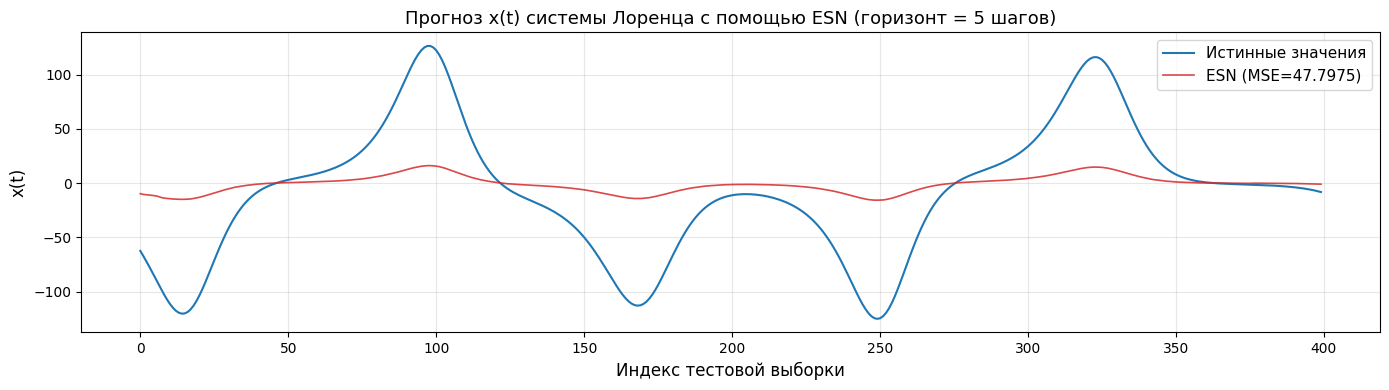

In [22]:
rf_esn = RandomForestRegressor(n_estimators=100).fit(
    states_tr_pca, Ytr[n_drop:, :].ravel()
)

Yhat_pca = rf_esn.predict(states_te_pca)[:, None]

mse_esn = mean_squared_error(
    Yte[n_drop:, :],
    Yhat_pca
)
print(f"ESN MSE (нормированный): {mse_esn:.4f}")

# График прогноза
n_plot_esn = 400
true_vals = scaler.inverse_transform(Yte[n_drop:, :])
pred_vals = scaler.inverse_transform(Yhat_pca)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(true_vals[:n_plot_esn], label='Истинные значения', color='tab:blue', lw=1.5)
ax.plot(pred_vals[:n_plot_esn], label=f'ESN (MSE={mse_esn:.4f})', color='tab:red', lw=1.2, alpha=0.85)
ax.set_xlabel('Индекс тестовой выборки', fontsize=12)
ax.set_ylabel('x(t)', fontsize=12)
ax.set_title(f'Прогноз x(t) системы Лоренца с помощью ESN (горизонт = {horizon} шагов)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


почему-то ESN линия плоская...

#### 5. 3D-визуализация состояний резервуара vs реальный аттрактор Лоренца

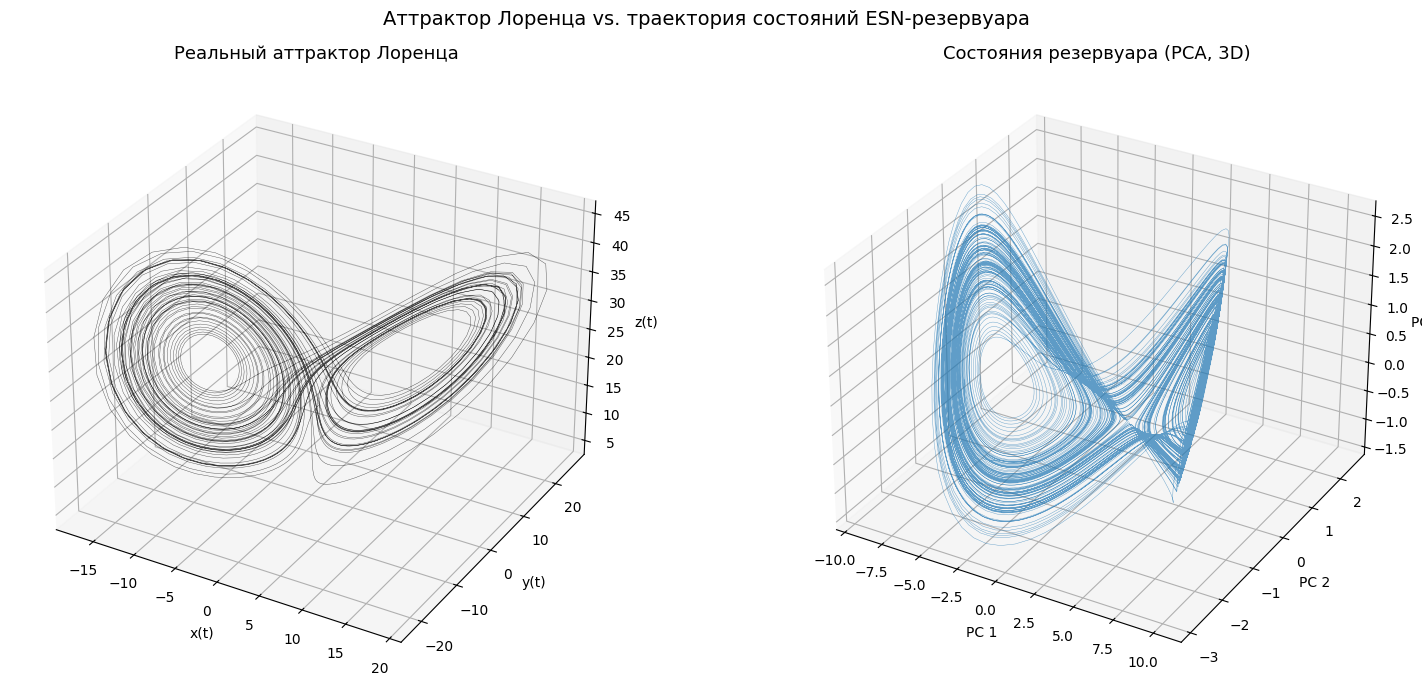

In [23]:
fig = plt.figure(figsize=(16, 7))

# Реальный аттрактор Лоренца
ax1 = fig.add_subplot(121, projection='3d')
step = 10
ax1.plot(lor_sol[0, ::step], lor_sol[1, ::step], lor_sol[2, ::step],
         linewidth=0.3, alpha=0.7, color='black')
ax1.set_title('Реальный аттрактор Лоренца', fontsize=13)
ax1.set_xlabel('x(t)', fontsize=10)
ax1.set_ylabel('y(t)', fontsize=10)
ax1.set_zlabel('z(t)', fontsize=10)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(states_tr_pca[:, 0], states_tr_pca[:, 1], states_tr_pca[:, 2],
         linewidth=0.3, alpha=0.7, color='tab:blue')
ax2.set_title('Состояния резервуара (PCA, 3D)', fontsize=13)
ax2.set_xlabel('PC 1', fontsize=10)
ax2.set_ylabel('PC 2', fontsize=10)
ax2.set_zlabel('PC 3', fontsize=10)

plt.suptitle('Аттрактор Лоренца vs. траектория состояний ESN-резервуара', fontsize=14)
plt.tight_layout()
plt.show()


ну собственно слева та самая бабочка, но визуализацимя резервуара немного отличается, но в общем повторяет форму. лопасти повёрнуты и вытянуты иначе, поскольку PCA выбирает направления максимальной дисперсии в пространстве состояний резервуара, а не в физическом пространстве системы. 

#### 6. Сравнение качества всех методов

In [24]:
print(f"{'Метод':<35} {'MSE':>10}")
print(f"{'Вложение Такенса + Ridge':<35} {mse_ridge:>10.4f}")
print(f"{'Вложение Такенса + Random Forest':<35} {mse_rf:>10.4f}")
print(f"{'ESN + Random Forest (PCA-3)':<35} {mse_esn:>10.4f}")


Метод                                      MSE
Вложение Такенса + Ridge               63.6234
Вложение Такенса + Random Forest        5.1693
ESN + Random Forest (PCA-3)            47.7975


Random Forest на вложениях Такенса показал лучший результат